# Лабораторна робота №1
## Задача 1


### 1. Поле напрямків

  За допомогою $np.meshgrid$ ми створюємо двовимірну сітку координат X_grid та Y_grid. Для кожної точки обчислюємо вектор напрямку. Компонента по осі x $U = 1$, а компонента по осі y $V = f(x,y) = y^2 - 2y + x$. Щоб всі стрілочки мали однакову довжину і графік виглядав охайно, ми нормалізуємо їх, ділячи на довжину вектора $N = \sqrt{U^2 + V^2}$. Функція $ax.quiver$ малює ці стрілочки.


### 2. Ізокліни ($k =\pm 0.5,\pm 1,\pm 1.5$)

  Рівняння $y^2 - 2y + x = k$ ми аналітично перетворили на $x = -y^2 + 2y + k$. У коді ми задаємо одновимірний масив y_iso (від -6 до 6), і в циклі для кожного значення $k$ масив x_iso обчислюється автоматично як парабола. Потім $ax.plot$ просто з'єднує ці точки.

### 3. Області зростання та спадання

  Спочатку обчислюється масив межі x_k0 = -y_iso**2 + 2*y_iso. Далі використовується функція $ax.fill_betweenx$. Вона зафарбовує простір по горизонталі: від лівого краю графіка (-6) до межі x_k0 (це область спадання, бо там $x$ менше за межу), і від межі x_k0 до правого краю (6) (область зростання).

### 4. Множина точок максимуму розв'язків

  Аналітично доведено, що друга похідна $y'' = 2(y-1)y' + 1$. На кривій $y' = 0$ друга похідна завжди дорівнює $1$ (а $1 > 0$). Тому точок максимуму не існує, є лише точки мінімуму. У коді ми просто додаємо відповідний підпис до червоної лінії нуль-ізокліни з попереднього пункту.

### 5. Області опуклості (вгору/вниз)

  Створюється дуже щільна сітка X_dense, Y_dense. Для кожної точки сітки обчислюється значення матриці Y_double_prime = 2*(y-1)*(y^2 - 2y + x) + 1. Функція $ax.contourf$ шукає регіони, де значення цієї матриці менше або дорівнює нулю (рівні levels=[-np.inf, 0]), і накладає туди штриховку //.

### 6. Множина точок перегину

  Оскільки у формулі є ділення на $(y-1)$, при $y=1$ виникає асимптота (розрив). Щоб графік не "зламався" через ділення на нуль, ми генеруємо два окремих масиви для ігрека: y_inf1 (строго менше 1) та y_inf2 (строго більше 1). Обчислюємо x для кожного з них і малюємо двома окремими лініями.

### 7. Інтегральні криві (чисельний метод)

  Використовується готовий розв'язувач solve_ivp з бібліотеки SciPy (метод Рунге-Кутти за замовчуванням).Оскільки він рахує лише "вперед" у часі, ми викликаємо його двічі для кожної точки: один раз для x від 0 до 6.5 (res_r), другий — від 0 до -6.5 (res_l).Щоб рівняння не видало помилку переповнення (коли значення стрімко летить у нескінченність), додано параметр events=stop_cond, який примусово зупиняє розрахунок, як тільки $|y|$ досягає 10.Далі масиви лівої та правої гілок "зшиваються" за допомогою np.concatenate (при цьому лівий масив перевертається [::-1], щоб координати йшли по зростанню від мінуса до плюса).

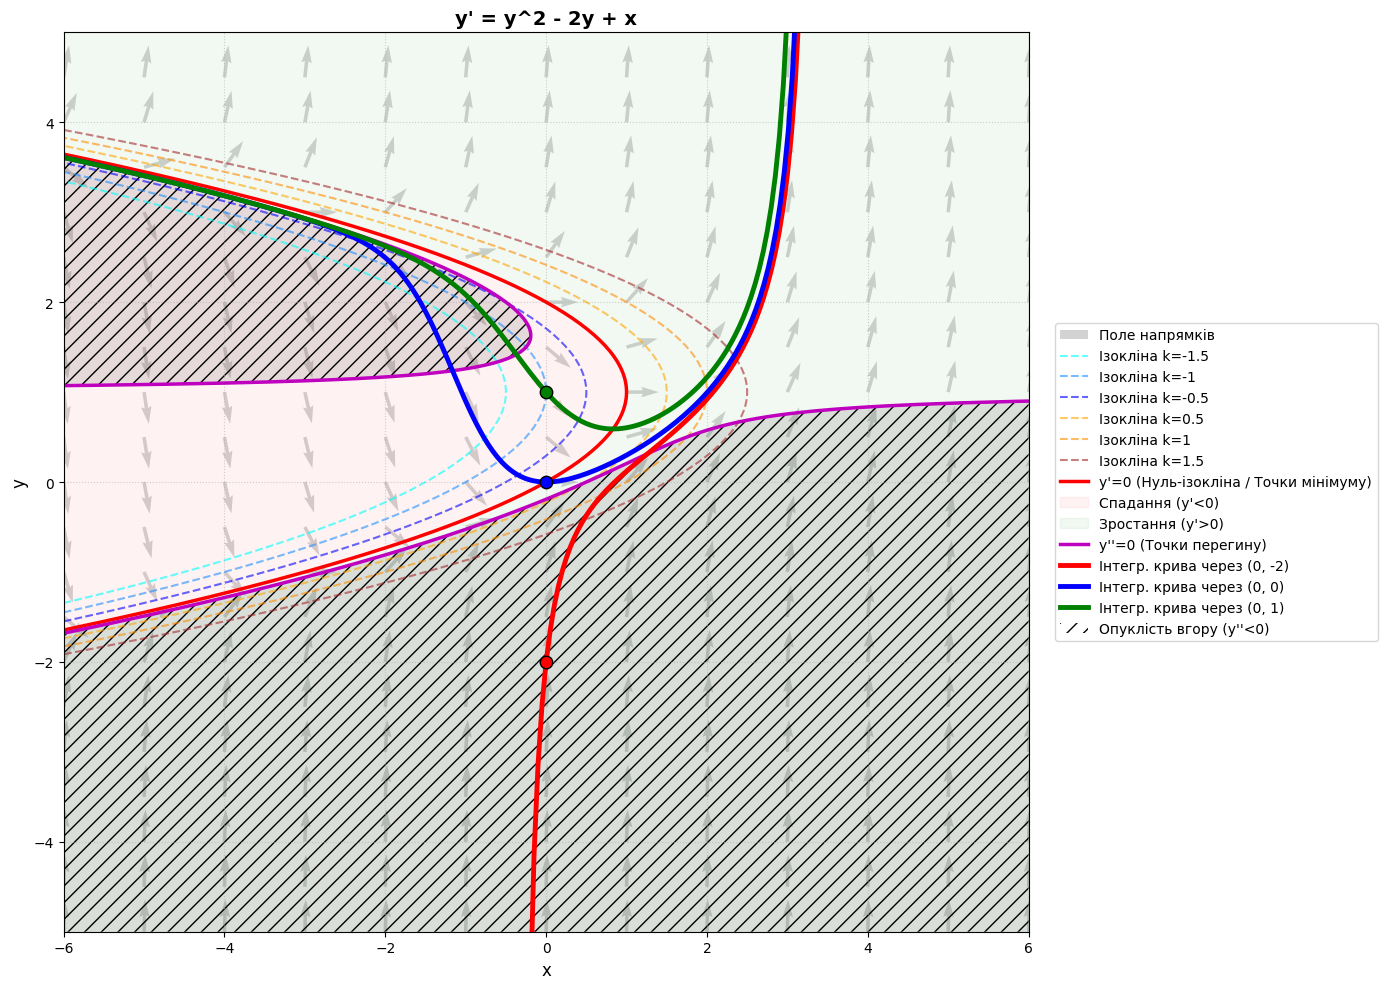

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.integrate import solve_ivp

# --- Задання рівняння ---
def eq(x, y):
    return y**2 - 2*y + x

def stop_cond(x, y):
    return 10.0 - np.abs(y[0])
stop_cond.terminal = True

# --- Налаштування графіка ---
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim([-6, 6])
ax.set_ylim([-5, 5])
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title("y' = y^2 - 2y + x", fontsize=14, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)

# =========================================================
# 1. Поле напрямків (m = -6..6, n/2 = -5..5)
# =========================================================
m_vals = np.arange(-6, 7, 1)
n_vals = np.arange(-10, 11, 1) / 2.0
X_grid, Y_grid = np.meshgrid(m_vals, n_vals)
U = np.ones_like(X_grid)
V = eq(X_grid, Y_grid)
N = np.sqrt(U**2 + V**2)
ax.quiver(X_grid, Y_grid, U/N, V/N, color='lightgray', angles='xy', scale=30, headwidth=3, label='Поле напрямків')

# =========================================================
# 2. Ізокліни (k = ±0.5, ±1, ±1.5)
# =========================================================
y_iso = np.linspace(-6, 6, 400)
k_values = [-1.5, -1, -0.5, 0.5, 1, 1.5]
iso_colors = ['cyan', 'dodgerblue', 'blue', 'orange', 'darkorange', 'brown']

for k, col in zip(k_values, iso_colors):
    x_iso = -y_iso**2 + 2*y_iso + k
    ax.plot(x_iso, y_iso, '--', color=col, linewidth=1.5, alpha=0.6, label=f'Ізокліна k={k}')

# =========================================================
# 3, 4. Нуль-ізокліна (y'=0) та області зростання/спадання
# =========================================================
x_k0 = -y_iso**2 + 2*y_iso
ax.plot(x_k0, y_iso, 'r-', linewidth=2.5, label="y'=0 (Нуль-ізокліна / Точки мінімуму)")

# Заливка областей зростання/спадання
ax.fill_betweenx(y_iso, -6, x_k0, color='red', alpha=0.05, label="Спадання (y'<0)")
ax.fill_betweenx(y_iso, x_k0, 6, color='green', alpha=0.05, label="Зростання (y'>0)")

# =========================================================
# 5, 6. Точки перегину (y''=0) та області опуклості
# =========================================================
# Розбиваємо на дві гілки через асимптоту y=1
y_inf1 = np.linspace(-6, 0.95, 400)
y_inf2 = np.linspace(1.05, 6, 400)
x_inf1 = -y_inf1**2 + 2*y_inf1 - 1/(2*(y_inf1-1))
x_inf2 = -y_inf2**2 + 2*y_inf2 - 1/(2*(y_inf2-1))

ax.plot(x_inf1, y_inf1, 'm-', linewidth=2.5, label="y''=0 (Точки перегину)")
ax.plot(x_inf2, y_inf2, 'm-', linewidth=2.5)

# Штриховка областей опуклості вгору
X_dense, Y_dense = np.meshgrid(np.linspace(-6, 6, 400), np.linspace(-5, 5, 400))
Y_double_prime = 2*(Y_dense - 1)*(Y_dense**2 - 2*Y_dense + X_dense) + 1
ax.contourf(X_dense, Y_dense, Y_double_prime, levels=[-np.inf, 0], colors='none', hatches=['//'], alpha=0.1)

# Ручна легенда для штриховки
hatch_patch = mpatches.Patch(facecolor='none', hatch='//', alpha=0.3, label="Опуклість вгору (y''<0)")

# =========================================================
# 7. Інтегральні криві (через задані точки)
# =========================================================
y_starts = [-2, 0, 1]
line_colors = ['red', 'blue', 'green']

for y0, col in zip(y_starts, line_colors):
    # Рахуємо вправо від 0
    res_r = solve_ivp(eq, (0, 6.5), [y0], dense_output=True, events=stop_cond, max_step=0.05)
    # Рахуємо вліво від 0
    res_l = solve_ivp(eq, (0, -6.5), [y0], dense_output=True, events=stop_cond, max_step=0.05)

    # Зшиваємо масиви
    t_full = np.concatenate((res_l.t[::-1], res_r.t[1:]))
    y_full = np.concatenate((res_l.y[0][::-1], res_r.y[0][1:]))

    # Малюємо криву та початкову точку
    ax.plot(t_full, y_full, color=col, lw=3.5, label=f'Інтегр. крива через (0, {y0})')
    ax.scatter(0, y0, color=col, edgecolor='black', s=80, zorder=5)

handles, labels = ax.get_legend_handles_labels()
handles.append(hatch_patch)
labels.append("Опуклість вгору (y''<0)")
ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10)

plt.tight_layout()
plt.show()

## Задача 2
Дано автономне диференціальне рівняння першого порядку:$$y' = y^2 - y$$де права частина $g(y) = y^2 - y$.

### 1. Векторне поле

Оскільки рівняння є автономним, кутовий коефіцієнт дотичної $k = y'$ залежить виключно від ординати $y$. Знайдемо значення похідної у заданих точках $y \in \{0, \pm 1, \pm 2, \pm 3, \pm 4\}$:$y = 0 \implies y' = 0^2 - 0 = 0$$y = 1 \implies y' = 1^2 - 1 = 0$$y = -1 \implies y' = (-1)^2 - (-1) = 2$$y = 2 \implies y' = 2^2 - 2 = 2$$y = -2 \implies y' = (-2)^2 - (-2) = 6$$y = 3 \implies y' = 3^2 - 3 = 6$$y = -3 \implies y' = (-3)^2 - (-3) = 12$$y = 4 \implies y' = 4^2 - 4 = 12$$y = -4 \implies y' = (-4)^2 - (-4) = 20$

### 2. Області зростання, спадання та точки перегину

Знайдемо нулі функції $g(y)$:$$y^2 - y = 0 \implies y_1 = 0, \quad y_2 = 1$$Область зростання ($y' > 0$): розв'язуючи нерівність $y(y - 1) > 0$, отримуємо $y \in (-\infty, 0) \cup (1, +\infty)$.Область спадання ($y' < 0$): розв'язуючи нерівність $y(y - 1) < 0$, отримуємо $y \in (0, 1)$.Для знаходження множини точок перегину знайдемо другу похідну:$$y'' = \frac{d}{dx}(y^2 - y) = 2yy' - y' = (2y - 1)y' = (2y - 1)(y^2 - y)$$Прирівняємо другу похідну до нуля:$$(2y - 1)y(y - 1) = 0$$Корені рівняння: $y = 0.5$, $y = 0$, $y = 1$. Оскільки $y=0$ та $y=1$ є стаціонарними розв'язками (горизонтальні прямі), то точки перегину інтегральних кривих лежать на прямій $y = 0.5$.

### 3. Явний вигляд розв'язку та інтервали існування

Розділимо змінні:$$\frac{dy}{y^2 - y} = dx$$Інтегруємо обидві частини, використовуючи розклад на елементарні дроби $\frac{1}{y(y-1)} = \frac{1}{y-1} - \frac{1}{y}$:$$\int \left( \frac{1}{y-1} - \frac{1}{y} \right) dy = \int dx \implies \ln\left|\frac{y-1}{y}\right| = x + C \implies \frac{y-1}{y} = C_0 e^x$$Знайдемо константу $C_0$ з початкової умови $y(0) = y_0$:$$C_0 = \frac{y_0 - 1}{y_0}$$Виразимо $y$:$$1 - \frac{1}{y} = \frac{y_0 - 1}{y_0} e^x \implies \frac{1}{y} = 1 - \frac{y_0 - 1}{y_0} e^x = \frac{y_0 - (y_0 - 1)e^x}{y_0}$$Отже, явний вигляд розв'язку:$$y(x, y_0) = \frac{y_0}{y_0 - (y_0 - 1)e^x}$$Знайдемо інтервали існування $I_{y_0}$, прирівнявши знаменник до нуля:$y_0 - (y_0 - 1)e^x = 0 \implies x^* = \ln\left(\frac{y_0}{y_0 - 1}\right)$.Якщо $y_0 \in [0, 1]$, знаменник не обертається в нуль. Інтервал існування $I_{y_0} = (-\infty, +\infty)$.Якщо $y_0 > 1$, асимптота $x^* > 0$. Оскільки $x=0 \in I_{y_0}$, то $I_{y_0} = \left(-\infty, \ln\frac{y_0}{y_0 - 1}\right)$.Якщо $y_0 < 0$, асимптота $x^* < 0$. Оскільки $x=0 \in I_{y_0}$, то $I_{y_0} = \left(\ln\frac{y_0}{y_0 - 1}, +\infty\right)$.

### 4. Збіжність розв'язків

За умовою $I = (a,b)$ — інтервал зростання, а $J = (b,c)$ — інтервал спадання. З пункту 2 маємо зростання на $(-\infty, 0)$ та спадання на $(0, 1)$. Отже, спільна межа $b = 0$.Розглянемо дві функції:$$y_A(x) = y(x, 0.5) = \frac{0.5}{0.5 - (-0.5)e^x} = \frac{1}{1 + e^x}$$$$y_B(x) = y(x, -0.5) = \frac{-0.5}{-0.5 - (-1.5)e^x} = \frac{1}{1 - 3e^x}$$Знайдемо $x \geq 0$, для якого $|y_A(x) - y_B(x)| < 10^{-3}$:$$\left| \frac{1}{1 + e^x} - \frac{1}{1 - 3e^x} \right| < 0.001$$Нехай $u = e^x$ ($u \geq 1$). Зведемо до спільного знаменника:$$\left| \frac{1 - 3u - (1 + u)}{(1 + u)(1 - 3u)} \right| = \frac{4u}{3u^2 + 2u - 1} < \frac{1}{1000}$$Оскільки при $u \geq 1$ знаменник додатний, маємо:$$4000u < 3u^2 + 2u - 1 \implies 3u^2 - 3998u - 1 > 0$$Шукаємо додатний корінь:$$u > \frac{1999 + \sqrt{1999^2 + 3}}{3} \approx 1332.667$$Повертаючись до $x$, отримуємо:$$x > \ln(1332.667) \approx 7.1949$$Отже, відстань між кривими стає меншою за $10^{-3}$ при $x > 7.1949$.

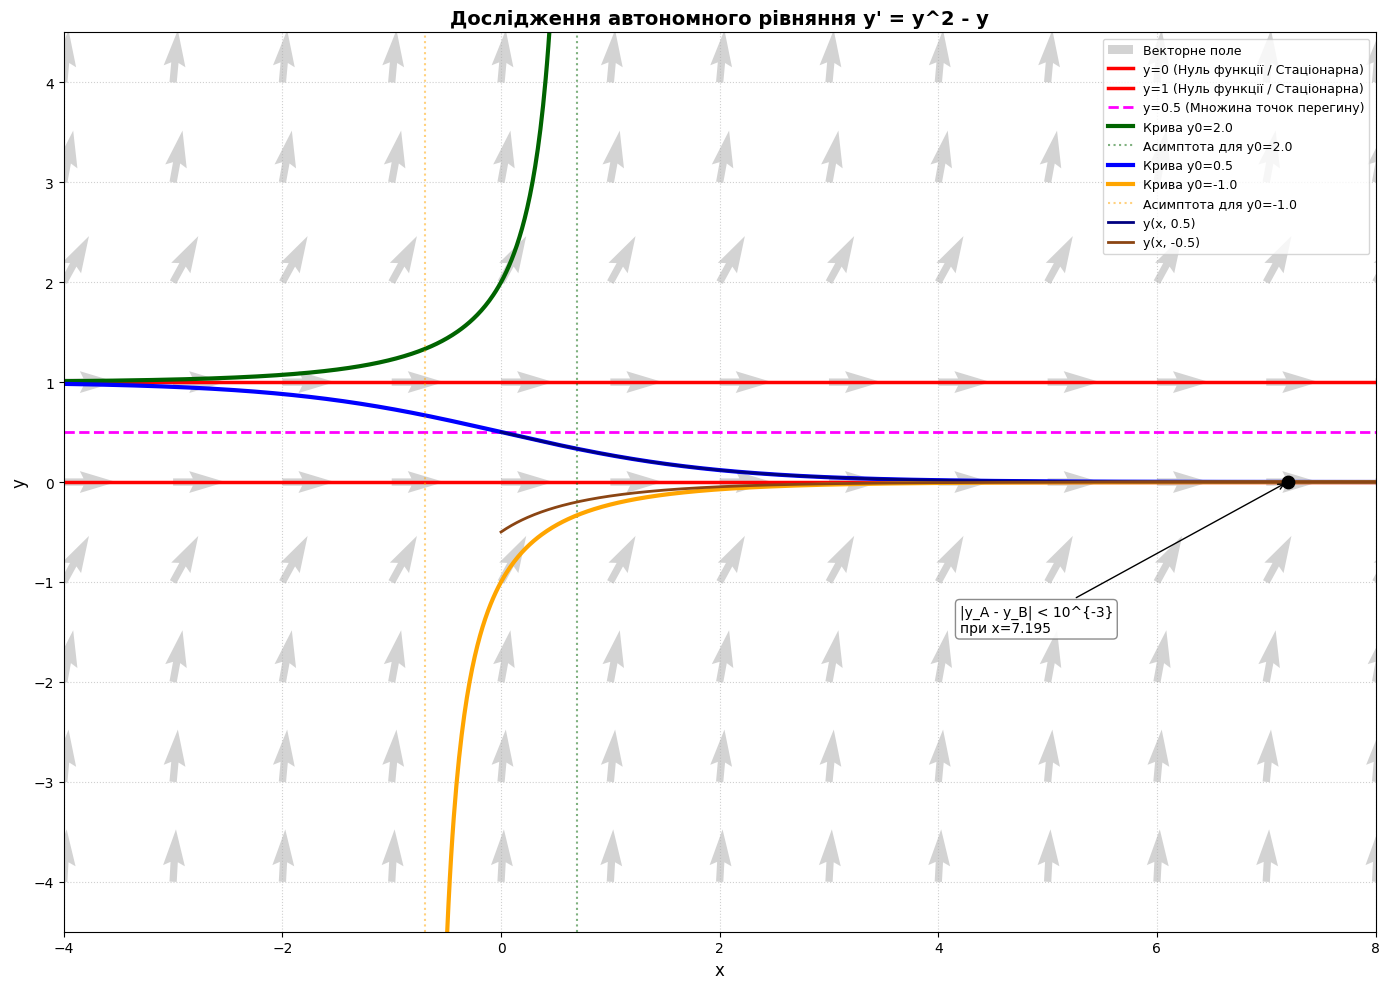

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Явний розв'язок y(x, y0)
def y_exact(x, y0):
    return y0 / (y0 - (y0 - 1) * np.exp(x))

# Налаштування графіка
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim([-4, 8])
ax.set_ylim([-4.5, 4.5])
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title("Дослідження автономного рівняння y' = y^2 - y", fontsize=14, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)

# =========================================================
# 1. Векторне поле (у заданих точках y = 0, ±1, ±2, ±3, ±4)
# =========================================================
x_vals = np.arange(-4, 9, 1)
y_vals = np.array([-4, -3, -2, -1, 0, 1, 2, 3, 4])
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
U = np.ones_like(X_grid)
V = Y_grid**2 - Y_grid
# Нормалізація векторів
N = np.sqrt(U**2 + V**2)
ax.quiver(X_grid, Y_grid, U/N, V/N, color='lightgray', angles='xy', scale=25, headwidth=3, label='Векторне поле')

# =========================================================
# 2. Точки перегину та стаціонарні розв'язки
# =========================================================
ax.axhline(0, color='red', linewidth=2.5, label='y=0 (Нуль функції / Стаціонарна)')
ax.axhline(1, color='red', linewidth=2.5, label='y=1 (Нуль функції / Стаціонарна)')
ax.axhline(0.5, color='magenta', linestyle='--', linewidth=2, label='y=0.5 (Множина точок перегину)')

# =========================================================
# 4. Графіки функції y(x, y0) для різних інтервалів
# =========================================================
x_dense = np.linspace(-4, 8, 1000)

# Представники з інтервалів (y0)
y0_list = [2.0, 0.5, -1.0] # y0 > 1, y0 in (0,1), y0 < 0
colors = ['darkgreen', 'blue', 'orange']

for y0, col in zip(y0_list, colors):
    y_vals_exact = y_exact(x_dense, y0)

    # Визначаємо асимптоти, щоб уникнути потворних з'єднань на графіку
    if y0 > 1 or y0 < 0:
        asymptote_x = np.log(y0 / (y0 - 1))
        # Маскуємо значення, які знаходяться за межами інтервалу існування Iy0
        if y0 > 1:
            mask = x_dense < asymptote_x - 0.05
        else:
            mask = x_dense > asymptote_x + 0.05

        ax.plot(x_dense[mask], y_vals_exact[mask], color=col, linewidth=3, label=f'Крива y0={y0}')
        ax.axvline(asymptote_x, color=col, linestyle=':', alpha=0.5, label=f'Асимптота для y0={y0}')
    else:
        ax.plot(x_dense, y_vals_exact, color=col, linewidth=3, label=f'Крива y0={y0}')

# =========================================================
# 5. Аналіз збіжності y(x, 0.5) та y(x, -0.5)
# =========================================================
x_pos = np.linspace(0, 8, 500)
yA = y_exact(x_pos, 0.5)
yB = y_exact(x_pos, -0.5)

ax.plot(x_pos, yA, color='navy', linestyle='-', linewidth=2, label='y(x, 0.5)')
ax.plot(x_pos, yB, color='saddlebrown', linestyle='-', linewidth=2, label='y(x, -0.5)')

# Точка, де відстань стає меншою за 10^-3
target_x = np.log((1999 + np.sqrt(1999**2 + 3)) / 3)
target_y = y_exact(target_x, 0.5) # Значення приблизно однакове для обох
ax.scatter([target_x], [target_y], color='black', s=80, zorder=5)
ax.annotate(f'|y_A - y_B| < 10^{{-3}}\nпри x={target_x:.3f}',
            xy=(target_x, target_y), xytext=(target_x - 3, target_y - 1.5),
            arrowprops=dict(facecolor='black', arrowstyle='->'),
            fontsize=10, bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9))

ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()